# Simulation study: stratified sampling vs. multi-frame approach

This notebook presents a short simulation script that compares the mean squared error (MSE) and relative bias between:

- **Stratified sampling**
- **Multi-frame approach**

## What the script covers
- Simulation setup
- Sampling procedures
- Comparison of results


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import bootstrap
import numpy as np
from typing import Dict, Iterable, Optional
from datetime import datetime
from Simulation import Simulation 
import Plots 


#
plots = Plots.Plots()

# STratified Sampling 


1. Call and set _Simulation_ for the purpose of the stratified sampling.
2. The class _Simulation_ simulate a sampling scenario (namely, generate, sample and evaluate the estimators with respect to the sampling design)
3. The initiization of _Simulation_ will account for two strategies, STS and MFS. In this context, only the latter will be considered
4. Evaluate two true observables, that is, the sum population and the Population in each stratum

In [2]:
#This simulation concerns the stratified sampling only

#this serves to initialize the Simulation Class -- proportional strategy
simulation = Simulation(allocation="proportional", strategy= "StS")
simulation_init_results = simulation.run_pipeline()

#this serves to initialize the Simulation Class -- optimal cot strategy
simulation_opt = Simulation(allocation="optimal_cost", strategy= "StS")
simulation_init_results_opt = simulation_opt.run_pipeline()

#get the true observables
Y_true = np.sum(simulation_init_results["population"]["y"])
Nq_true_equal = np.sum(simulation_init_results["population"]["Nq"])

Proportional Allocation -- Extraction:
nq -- Sample size per frame: [198, 198, 204]
Sampling fraction per frame: [0.2, 0.2, 0.2]
----------------------
Proportional Allocation:
Nq -- Total per frame: [ 990  990 1020]
nq -- Sample size per frame: [198. 198. 204.]
Sampling fraction per frame: 0.2
----------------------
Optimal Cost Allocation -- Extraction Stratified Sampling:
nq -- Sample size per frame: [345, 330, 327]
Sampling fraction per frame: [0.3440307  0.32956298 0.32640632]
----------------------
Optimal Cost Allocation:
Nq -- Total per frame: [ 990  990 1020]
nq -- Sample size per frame: [213 171 217]
Sampling fraction per frame: [0.35472055 0.2838148  0.36146465]
----------------------


# Estimate parameters via Monte Carlo

- `Y_STS`: total population under STS
- `VAR_Y_STS`: variance of the total population under STS
- `mu_STS`: population mean for STS


In [3]:
#inital time
dinit = datetime.now()
R = 25 #number of MonteCarlo runs

#Save the estimates
estimates = {
     "Y_STS": np.hstack([np.array([Simulation(reproduce=False, allocation= "proportional", strategy="StS").run_pipeline()["estimates"]["Y_STS"] for rr in range(R)]), 
                       np.array([Simulation(reproduce=False, allocation= "optimal_cost", strategy="StS").run_pipeline()["estimates"]["Y_STS"] for rr in range(R)])]),
      'Var_Y_STS': np.hstack([np.array([Simulation(reproduce=False, allocation= "proportional", strategy="StS").run_pipeline()["estimates"]["Var_Y_STS"] for rr in range(R)]), 
                       np.array([Simulation(reproduce=False, allocation= "optimal_cost", strategy="StS").run_pipeline()["estimates"]["Var_Y_STS"] for rr in range(R)])]),
       "mu_STS" :  np.hstack([np.array([Simulation(reproduce=False, allocation= "proportional", strategy="StS").run_pipeline()["estimates"]["mu_STS"] for rr in range(R)]), 
                       np.array([Simulation(reproduce=False, allocation= "optimal_cost", strategy="StS").run_pipeline()["estimates"]["mu_STS"] for rr in range(R)])]),
        }


#Save the allocations
allocations = np.hstack([np.repeat("proportional", R), np.repeat("optimal_cost", R)])  # e.g., ["prop-x", "equal", "cost-opt", ...] per run
#time final
dfinal = datetime.now()
print(dfinal-dinit)

Proportional Allocation -- Extraction:
nq -- Sample size per frame: [198, 198, 204]
Sampling fraction per frame: [0.2, 0.2, 0.2]
----------------------
Proportional Allocation:
Nq -- Total per frame: [ 990  990 1020]
nq -- Sample size per frame: [198. 198. 204.]
Sampling fraction per frame: 0.2
----------------------
Proportional Allocation -- Extraction:
nq -- Sample size per frame: [198, 198, 204]
Sampling fraction per frame: [0.2, 0.2, 0.2]
----------------------
Proportional Allocation:
Nq -- Total per frame: [ 990  990 1020]
nq -- Sample size per frame: [198. 198. 204.]
Sampling fraction per frame: 0.2
----------------------
Proportional Allocation -- Extraction:
nq -- Sample size per frame: [198, 198, 204]
Sampling fraction per frame: [0.2, 0.2, 0.2]
----------------------
Proportional Allocation:
Nq -- Total per frame: [ 990  990 1020]
nq -- Sample size per frame: [198. 198. 204.]
Sampling fraction per frame: 0.2
----------------------
Proportional Allocation -- Extraction:
nq -

In [4]:
# Evaluate the MSE
DF = pd.DataFrame(estimates)
DF["allocation"] = allocations
true_value = 1

DFgb = DF.groupby("allocation")
for key, index in DFgb:
    dg= DFgb.get_group(key)
    mse = (dg["mu_STS"] -1)**2
    bootstrap_result = bootstrap((mse,), np.mean)

    print("===================================")
    print(f" === {key} ===")
    print(mse.mean())
    print(bootstrap_result.confidence_interval.low)
    print(bootstrap_result.confidence_interval.high)
    print('===================================')

 === optimal_cost ===
9.535136003310958e-06
6.030907640156535e-06
1.4152693635086261e-05
 === proportional ===
8.402115969466542e-06
5.150948896087115e-06
1.4404065011402667e-05


/Users/pinguino/Documents/-Population-Detection-and-Sampling-in-Liguria/Simulation/Plots.py:180: UserWarning: The palette list has more values (3) than needed (1), which may not be intended.
  ax = sns.boxplot(


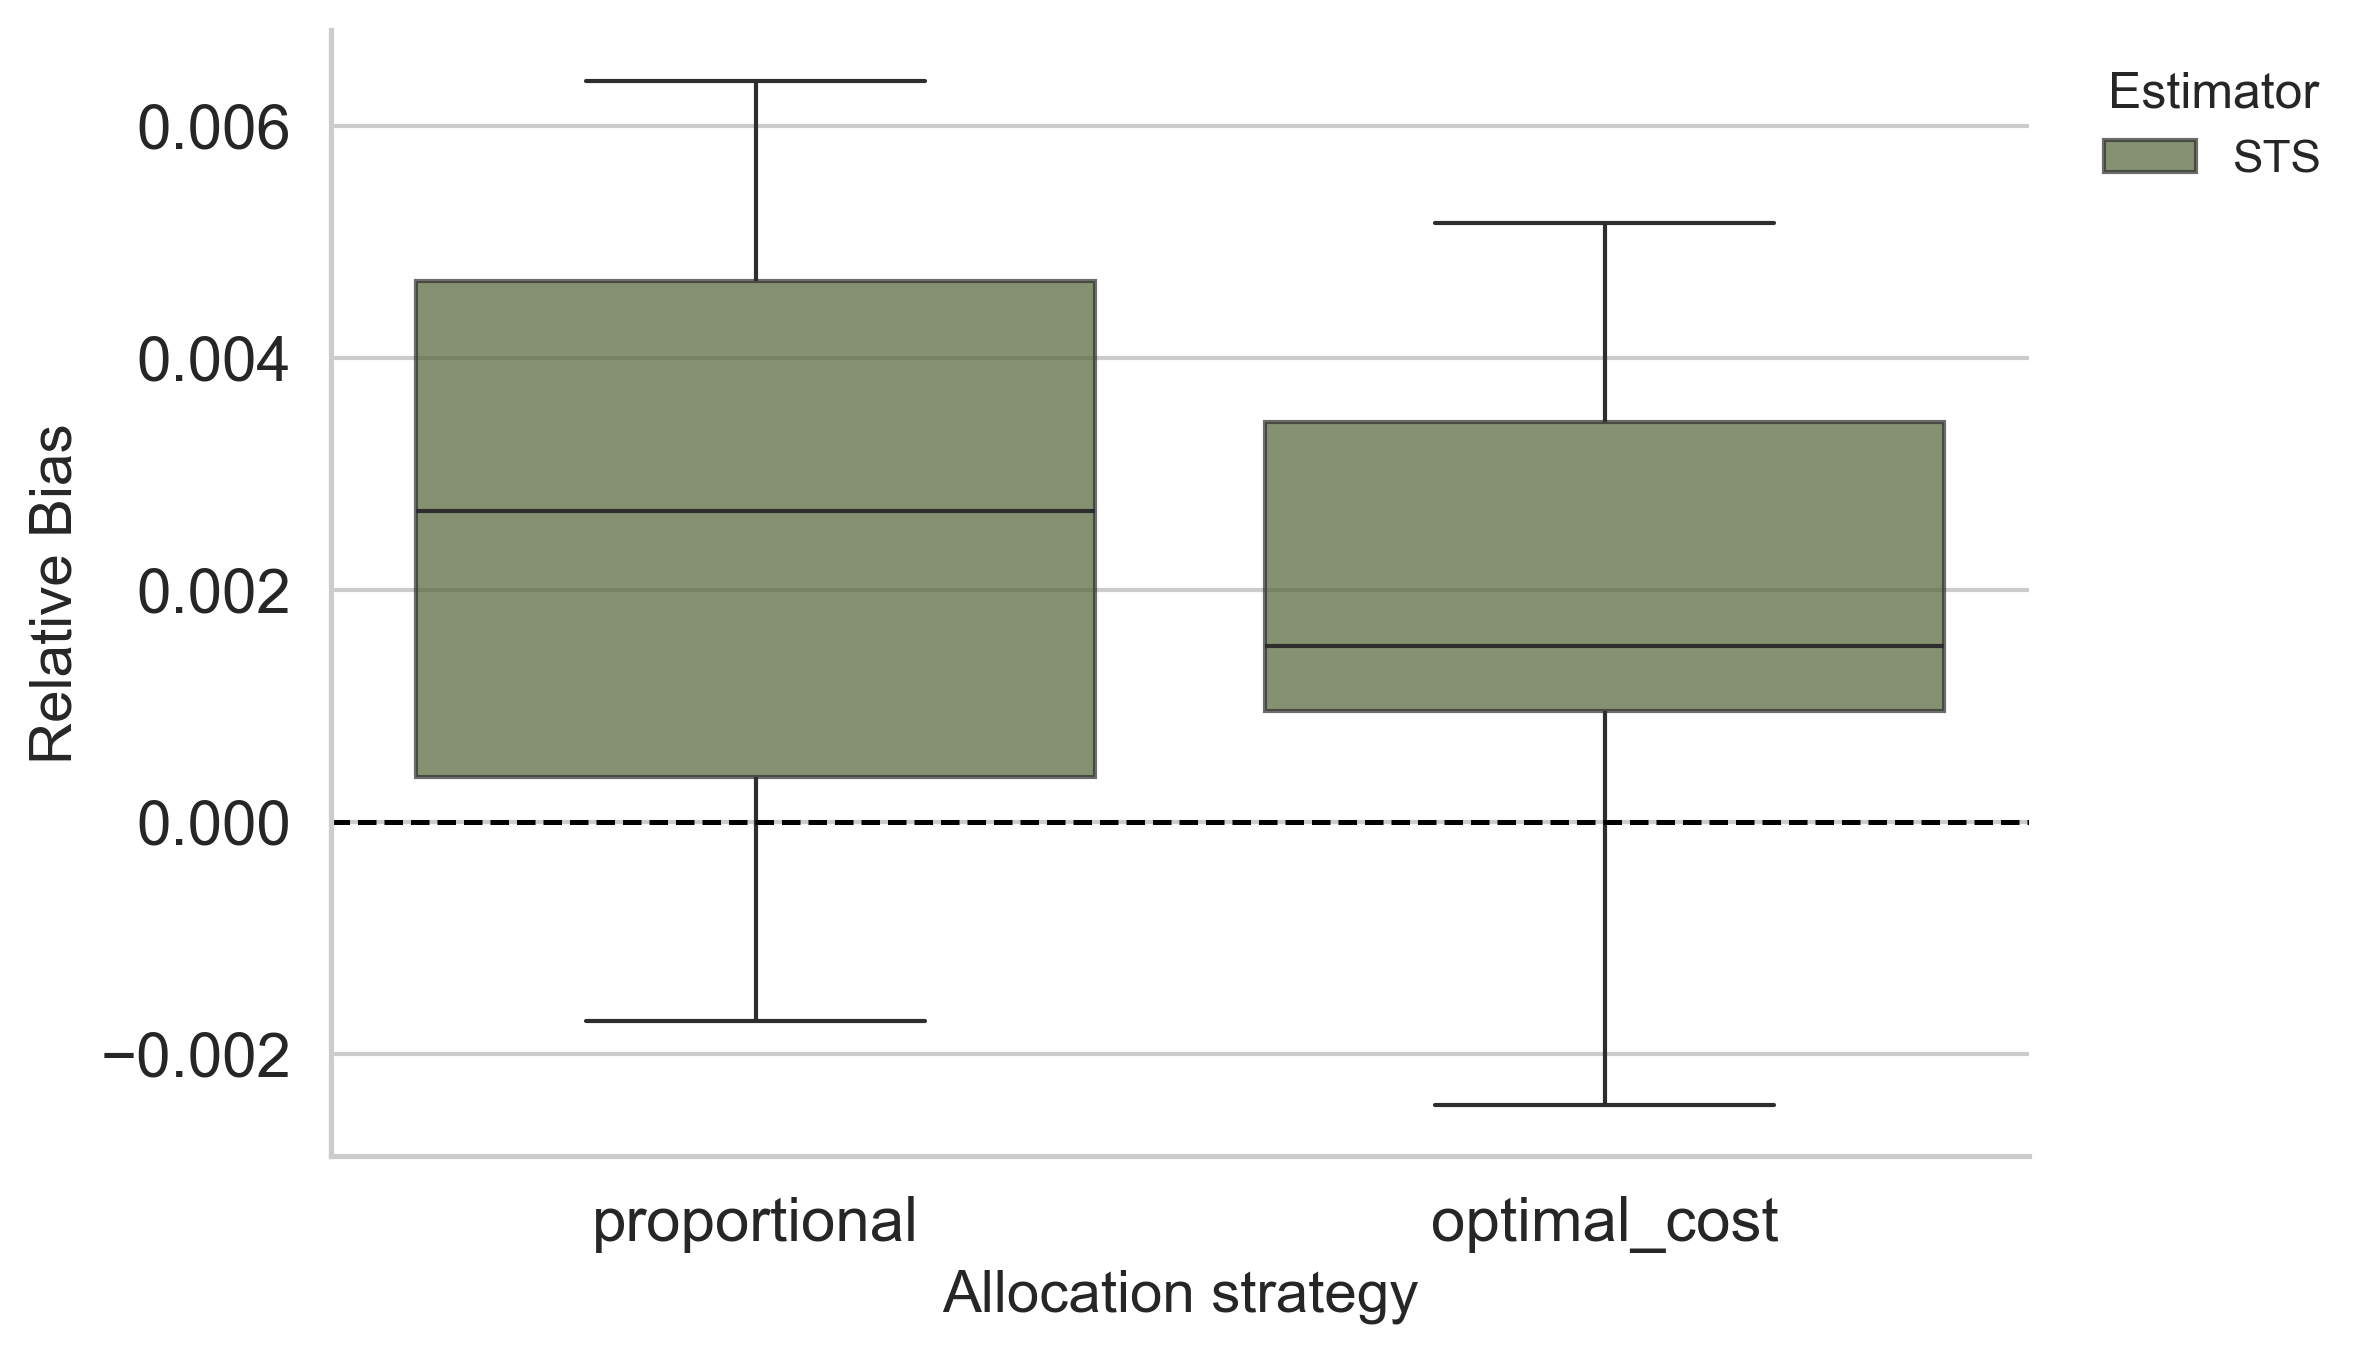

     allocation Estimator         MSE     CI_low     CI_high   n
0  optimal_cost       STS   61.952501  35.519818   91.595755  25
1  proportional       STS  115.687028  72.666404  162.768712  25


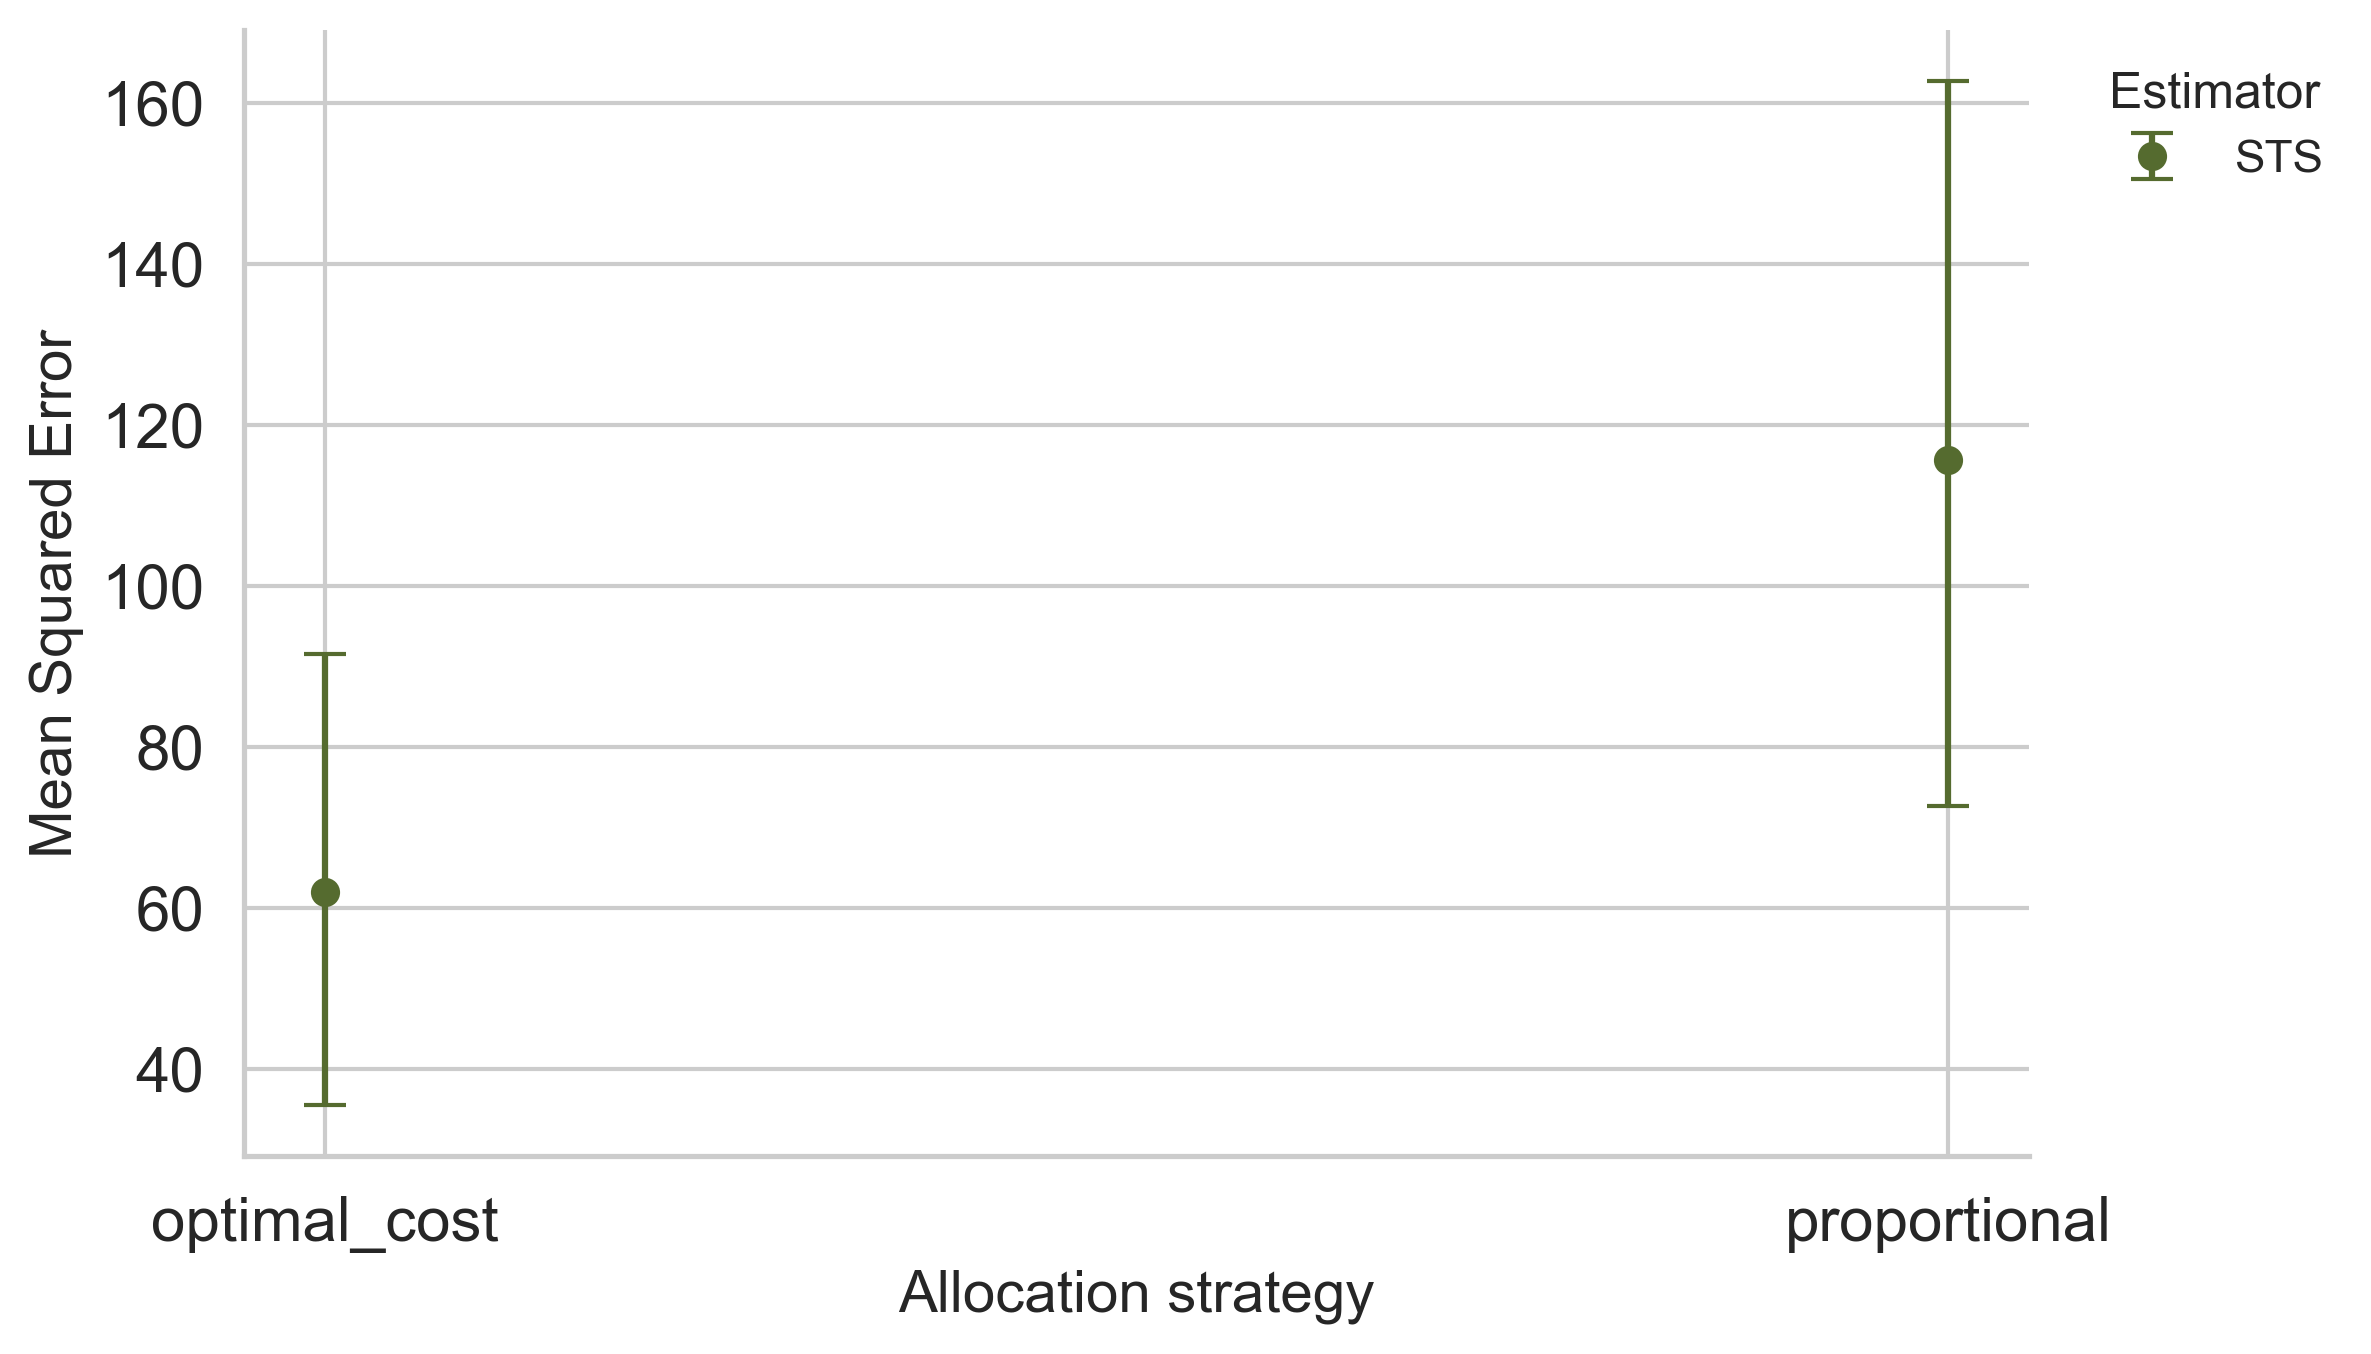

In [5]:
plots.plot_relative_error(estimates, Y_true, allocations, save="KSTS_relative_bias.pdf", kind = "STS")
plots.plot_mse(estimates, Y_true, allocations, save="KSTS_mse.pdf", kind = "STS")

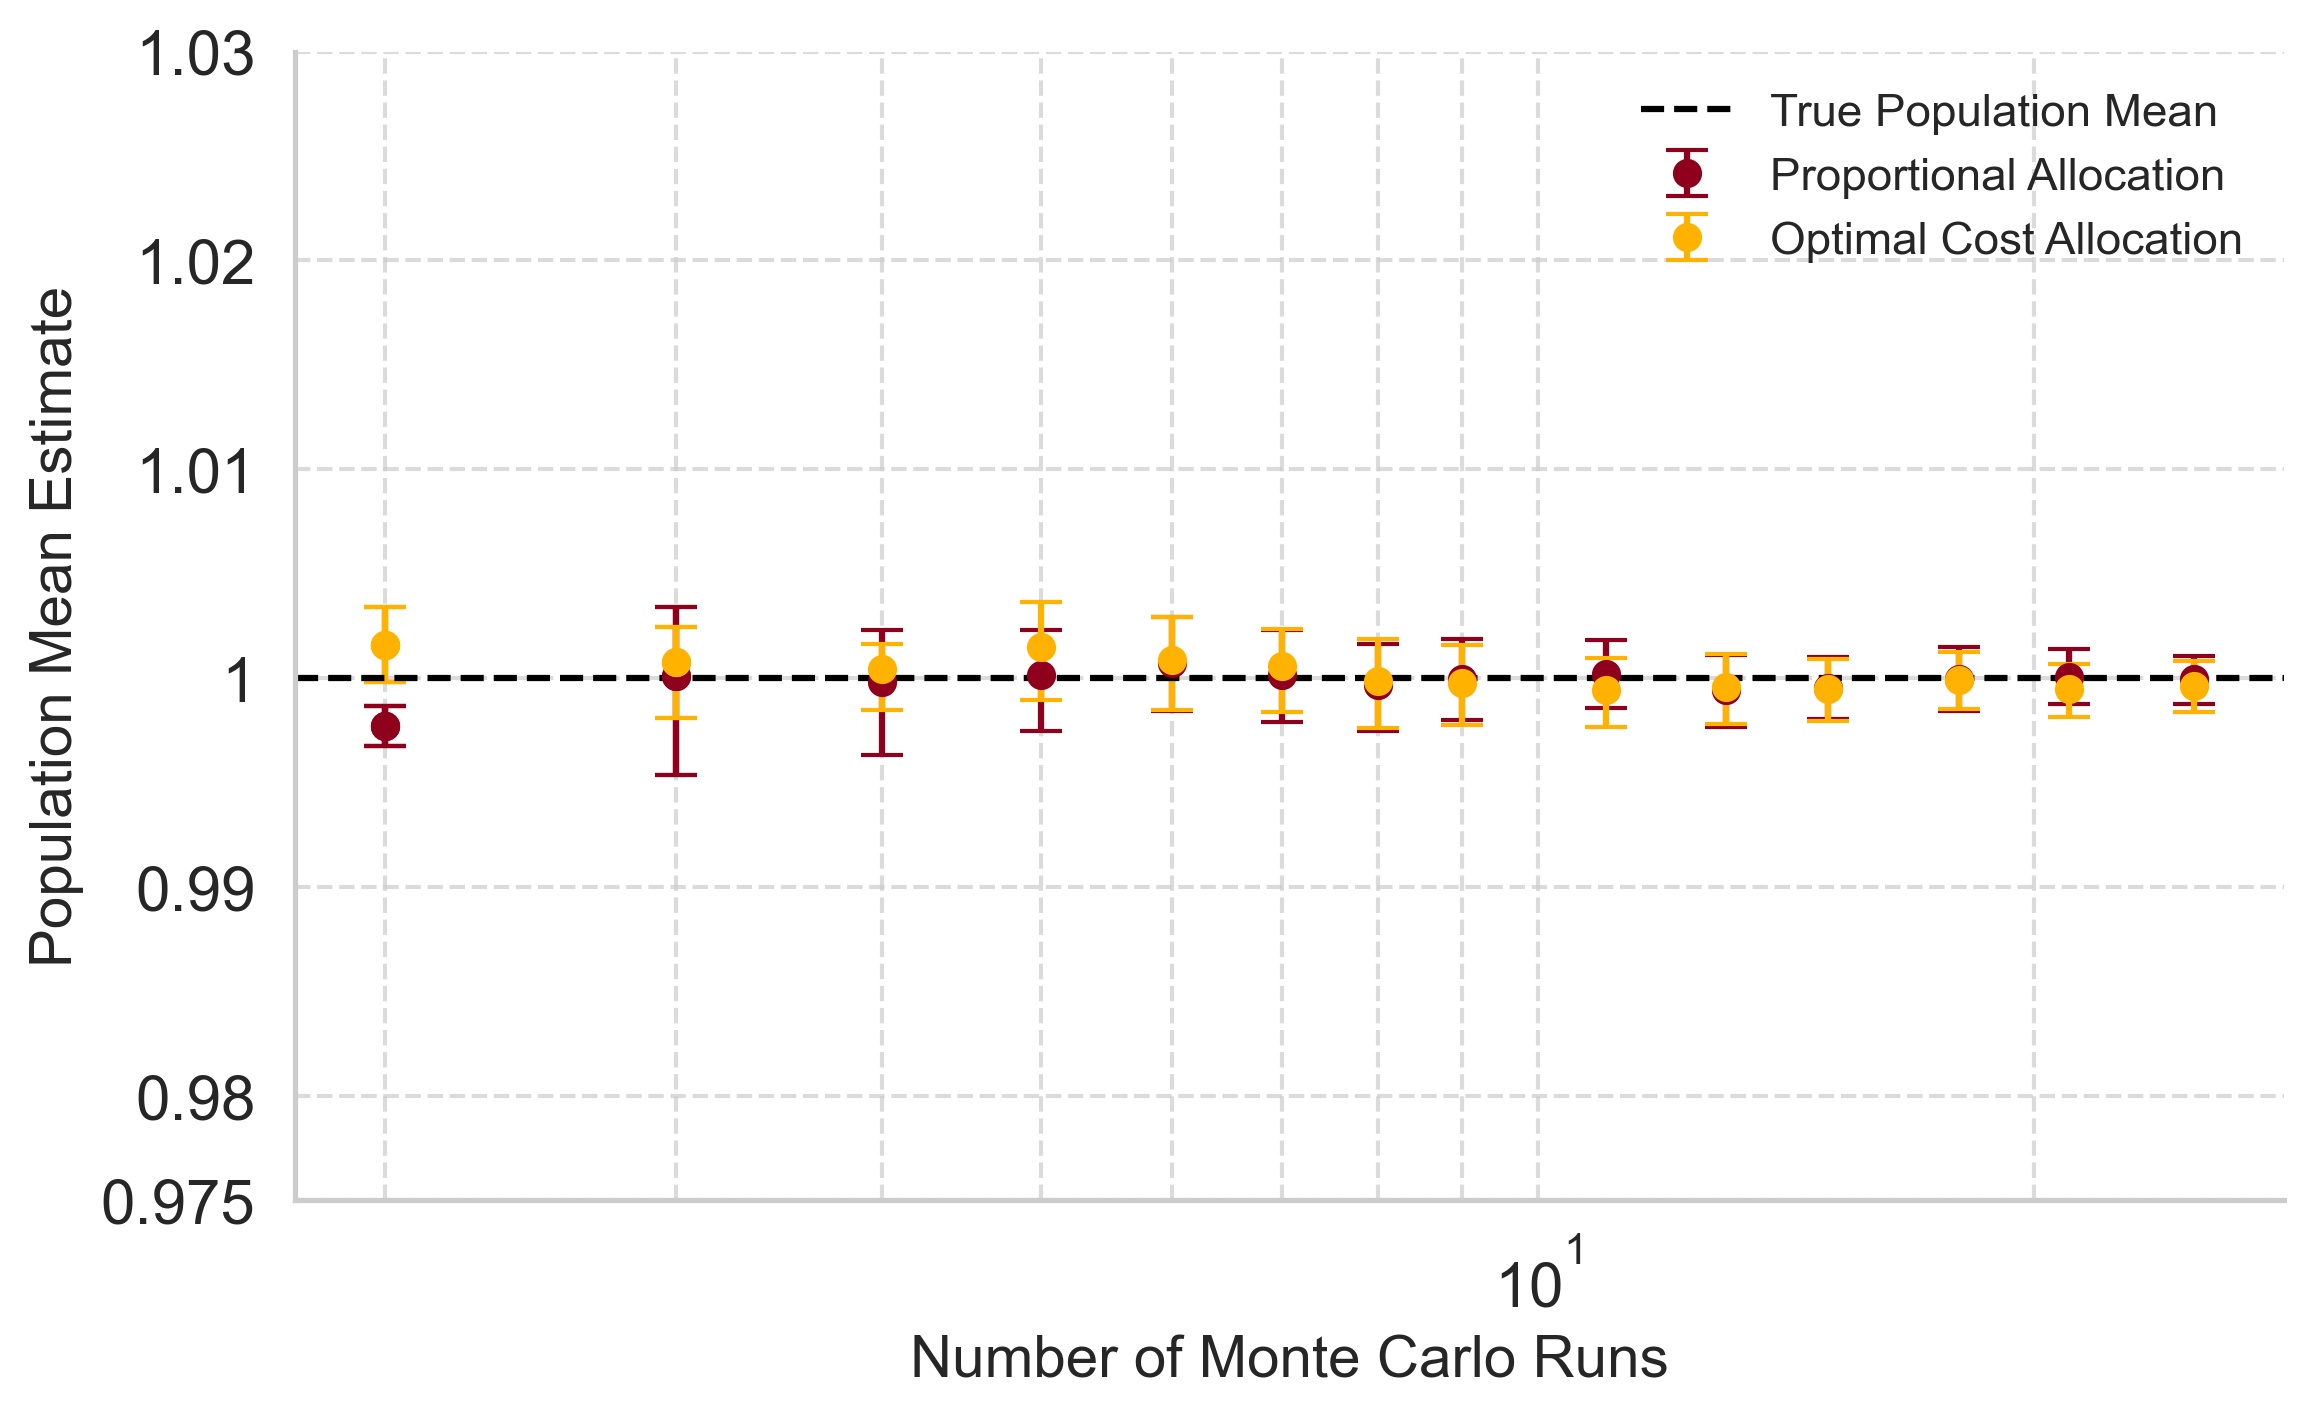

{'batch_sizes': array([ 2,  2,  2,  3,  3,  4,  5,  6,  7,  8,  9, 11, 13, 15, 18, 21, 25]),
 'prop': array([[0.99772496, 0.99676883, 0.9986811 ],
        [0.99772496, 0.99676883, 0.9986811 ],
        [0.99772496, 0.99676883, 0.9986811 ],
        [1.00008148, 0.99536844, 1.00339413],
        [1.00008148, 0.99536844, 1.00339413],
        [0.99979842, 0.99633068, 1.00228291],
        [1.00012411, 0.99747119, 1.00227839],
        [1.00071807, 0.99840624, 1.00293483],
        [1.00013297, 0.99791708, 1.00228885],
        [0.99967265, 0.99744856, 1.00164508],
        [0.99996246, 0.99797674, 1.00187532],
        [1.00019794, 0.99854534, 1.00183056],
        [0.99942256, 0.997673  , 1.00110317],
        [0.99953797, 0.99802708, 1.0010229 ],
        [0.99997671, 0.99843781, 1.00148031],
        [1.00005698, 0.99874188, 1.00138998],
        [0.99993321, 0.99876356, 1.00104149]]),
 'opt': array([[1.00160132, 0.99979115, 1.00341149],
        [1.00160132, 0.99979115, 1.00341149],
        [1.00160

In [6]:
#analysis of population mean -- how and whether Monte Carlo results converges to the true value
plots.analyze_population_mean(
        estimates = estimates,
        R = R,
        true_value = 1, 
        save_path = "KSTS_population_mean.pdf", 
        kind = "STS")

# Estimate parameters via Monte Carlo

- `Y_STS`: total population under MFS
- `VAR_Y_STS`: variance of the total population under MFS
- `mu_STS`: population mean for MFS

In [7]:
#This simulation concerns the MFS sampling
#this serves to initialize
simulation = Simulation(allocation="proportional", strategy= "MFS")
simulation_init_results = simulation.run_pipeline()

simulation_opt = Simulation(allocation="optimal_cost", strategy= "MFS")
simulation_init_results_opt = simulation_opt.run_pipeline()


Y_true = np.sum(simulation_init_results["population"]["y"])
Nq_true_equal = np.sum(simulation_init_results["population"]["Nq"])

Proportional Allocation -- Extraction:
nq -- Sample size per frame: [198, 198, 204]
Sampling fraction per frame: [0.2, 0.2, 0.2]
----------------------
Optimal Cost Allocation -- Extraction Multi-Frame Sampling:
nq -- Sample size per frame: [262, 414, 327]
Sampling fraction per frame: [0.26124821 0.41272257 0.32602922]
----------------------


In [8]:
# Suppose you have arrays from R runs with the same length:
R = 25
estimates = {
     "mu_SM": np.hstack([np.array([Simulation(reproduce=False, allocation= "proportional", strategy="MFS").run_pipeline()["estimates"]["mu_SM"] for rr in range(R)]), 
                       np.array([Simulation(reproduce=False, allocation= "optimal_cost", strategy="MFS").run_pipeline()["estimates"]["mu_SM"] for rr in range(R)])]),
     "mu_PML": np.hstack([np.array([Simulation(reproduce=False, allocation= "proportional", strategy="MFS").run_pipeline()["estimates"]["mu_PML"] for rr in range(R)]), 
                       np.array([Simulation(reproduce=False, allocation= "optimal_cost", strategy="MFS").run_pipeline()["estimates"]["mu_PML"] for rr in range(R)])])
      
}

allocations = np.hstack([np.repeat("proportional", R), np.repeat("optimal_cost", R)])  # e.g., ["prop-x", "equal", "cost-opt", ...] per run

Proportional Allocation -- Extraction:
nq -- Sample size per frame: [198, 198, 204]
Sampling fraction per frame: [0.2, 0.2, 0.2]
----------------------
Proportional Allocation -- Extraction:
nq -- Sample size per frame: [198, 198, 204]
Sampling fraction per frame: [0.2, 0.2, 0.2]
----------------------
Proportional Allocation -- Extraction:
nq -- Sample size per frame: [198, 198, 204]
Sampling fraction per frame: [0.2, 0.2, 0.2]
----------------------
Proportional Allocation -- Extraction:
nq -- Sample size per frame: [198, 198, 204]
Sampling fraction per frame: [0.2, 0.2, 0.2]
----------------------
Proportional Allocation -- Extraction:
nq -- Sample size per frame: [198, 198, 204]
Sampling fraction per frame: [0.2, 0.2, 0.2]
----------------------
Proportional Allocation -- Extraction:
nq -- Sample size per frame: [198, 198, 204]
Sampling fraction per frame: [0.2, 0.2, 0.2]
----------------------
Proportional Allocation -- Extraction:
nq -- Sample size per frame: [198, 198, 204]
Samp

In [ ]:
# Evaluate the MSE
DF = pd.DataFrame(estimates)
DF["allocation"] = allocations
true_value = 1

# SM
DFgb = DF.groupby("allocation")
for key, index in DFgb:
    dg= DFgb.get_group(key)
    mse = (dg["mu_SM"] -1)**2
    bootstrap_result = bootstrap((mse,), np.mean)

    print("===================================")
    print("========== SM =====================")
    print(f" === {key} ===")
    print(mse.mean())
    print(bootstrap_result.confidence_interval.low)
    print(bootstrap_result.confidence_interval.high)
    print('===================================')


#PML
DFgb = DF.groupby("allocation")
for key, index in DFgb:
    dg= DFgb.get_group(key)
    mse = (dg["mu_PML"] -1)**2
    bootstrap_result = bootstrap((mse,), np.mean)

    print("===================================")
    print("==== PML ==========================")
    print(f" === {key} ===")
    print(mse.mean())
    print(bootstrap_result.confidence_interval.low)
    print(bootstrap_result.confidence_interval.high)
    print('===================================')

 === optimal_cost ===
0.00013508412299497659
9.51432044935362e-05
0.00020987768176738858
 === proportional ===
0.0002677935882057987
0.00016531245494436306
0.00041093795892305197
 === optimal_cost ===
0.00015504140836476
9.789434773718197e-05
0.00023335947470005125
 === proportional ===
0.00020883806888148557
0.00011885785368708048
0.00038378279711697924
